In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit
import pandas as pd
import numpy as np

# Ajuste a grafica "stoping powers"

A partir de la gráfica adjunta de “stopping Powers” ( dE/dx ) de protones en Silicio, encuentre una relación que
permita obtener el valor de ( dE/dx ) en función de la energía E de los protones.
Puede ser una tabla “E”_vs_“dE/dx” y hacer un ajuste de un polinomio de grado 2 para hallar ( dE/dx ) para
cualquier valor de E

In [2]:
from utilities.ajuste  import ajuste_stopping_power, modelo

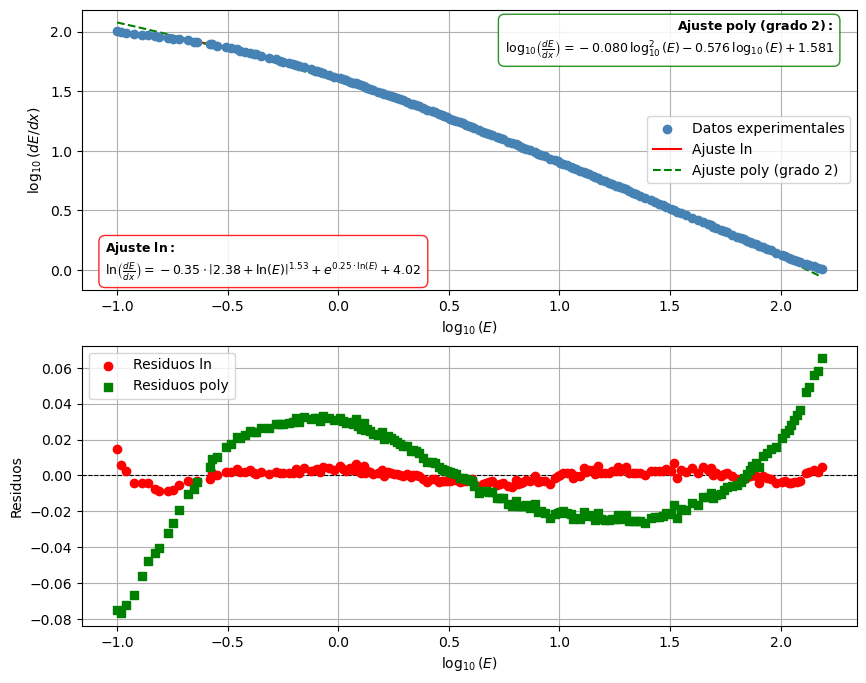

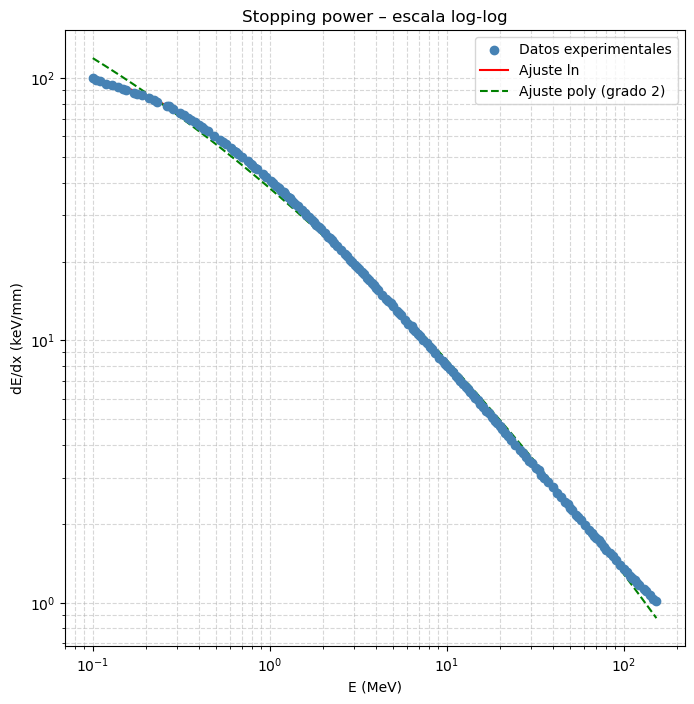

In [3]:
(fig1, fig2), (model_ln, model_poly), (popt, pcov, poly_coef) = ajuste_stopping_power()

el modelo resulta ser 
$$
\ln \left (\frac{dE}{dx}[KeV]\right) = -0.35\cdot |2.38 + \ln(E[Mev])|^{1.53} + e^{0.25\cdot \ln (E)}+4.02
$$

# Calculo numerico del alcanze de protones en silicio

Realice un cálculo numérico de los protones avanzando en el Silicio por pasos de espesor deltaX muy pequeño:
Se va avanzando en la profundidad X alcanzada por pasos deltaX:
Profundidad X nueva = Profundidad X anterior + deltaX
En esa nueva profundidad X determinamos la energía:
(Energía nueva) = (Energía anterior) – (dE/dx)*deltaX.
El valor de (dE/dx) es el que corresponde a la (Energía anterior).
Guarde en un arreglo el par de datos: {profundidad X actual, deltaE=(dE/dx)*deltaX}
Se repite avanzando en la profundidad X hasta que la (Energía nueva) sea menor o igual a cero.
Cuando se alcance energía cero, o menor, el valor de la profundidad X es el alcance R (range). Dé esto como
respuesta b.

In [17]:
def euler_range(model, E0=100.0, dx=0.01, E_stop=1e-3):
    """Euler simulation of proton slowing down in Si.
    model(E) -> dE/dx [keV/mm],  E in MeV, dx in mm.
    Returns arrays: x [mm], E [MeV], dEdx [keV/mm].
    """
    E, x = E0, 0.0
    x_list, E_list, dEdx_list = [x], [E], []
    while E >= E_stop:
        dEdx  = float(model(np.array([E]))[0])   # keV/mm
        E    -= dEdx * dx                 # convert keV→MeV
        x    += dx
        dEdx_list.append(dEdx)
        x_list.append(x)
        E_list.append(E)
    return np.array(x_list), np.array(E_list), np.array(dEdx_list)


x_ln,   E_ln,   dEdx_ln   = euler_range(model_ln,E_stop=1e-3)
x_poly, E_poly, dEdx_poly = euler_range(model_poly,E_stop=1e-3)
x_ln_E1,   _,   _   = euler_range(model_ln,E_stop=1e-3)
x_poly_E1, _, _ = euler_range(model_poly,E_stop=1e-3)

print(f"depth(0MeV) (ln fit)  : {x_ln[-1]:.4f} mm")
print(f"depth (0MeV) (poly fit): {x_poly[-1]:.4f} mm")

print(f"depth (1MeV) (ln fit)  : {x_ln_E1[-1]:.4f} mm")
print(f"depth (1MeV) (poly fit): {x_poly_E1[-1]:.4f} mm")

depth(0MeV) (ln fit)  : 41.9300 mm
depth (0MeV) (poly fit): 41.8400 mm
depth (1MeV) (ln fit)  : 41.9300 mm
depth (1MeV) (poly fit): 41.8400 mm


No resulta una diferencia significativa entre deterner la simulacion en $1MeV$ y $0MeV$ esto resulta asi que en la tabla tomada [1] de valores rangos para protones con $1MeV$ en silicio es de $0.0170mm$ que es mucho mas pequeño que el alcance que se esta teniendo de alrededor de $42mm$ ciertamente entrando en el rango de apreciacion del modelo, al comparar ambos modelos ln fit (mas exacto) y el poly fit (mas simple) la diferencia tambien resulta minima mostrando que el modelo polimonial de grado 2 resulta ser un fit valido para estos rangos de energia

![Approx_ranges.png](/home/thomas/Documents/aceleradores/trabajo_compu_2/data/table_aproximate.png)


# Comparacion teoria con modelo

Compare el resultado de R, obtenido aplicando el cálculo numérico por pasos con lo que muestra la gráfica de
RANGE DIFFERENCE para protones avanzando en Silicio. Comente la exactitud alcanzada con su cálculo
numérico por pasos

utilizando la grafica "range diferences for silicon" tomada de [1]

![range_diff.png](/home/thomas/Documents/aceleradores/trabajo_compu_2/data/range_diff_silic.jpeg)

se pude observar que Range teorico es alrededor de $40mm$ lo cual comparado con los resultados del modelo mas exacto y el polimonial de grado 2 de $41.93mm$ y $41.84mm$ respectivamente se puede conlcuir que se tiene una muy buena aproximacion y con datos mas detallados se podria tener una aun mejor



# graficas 
Realice una gráfica de deltaE vs. X (en el eje vertical el deltaE, en el eje horizonal X). ¿Cómo aumenta la perdida
de energía deltaE, a medida que avanza en profundidad la partícula?

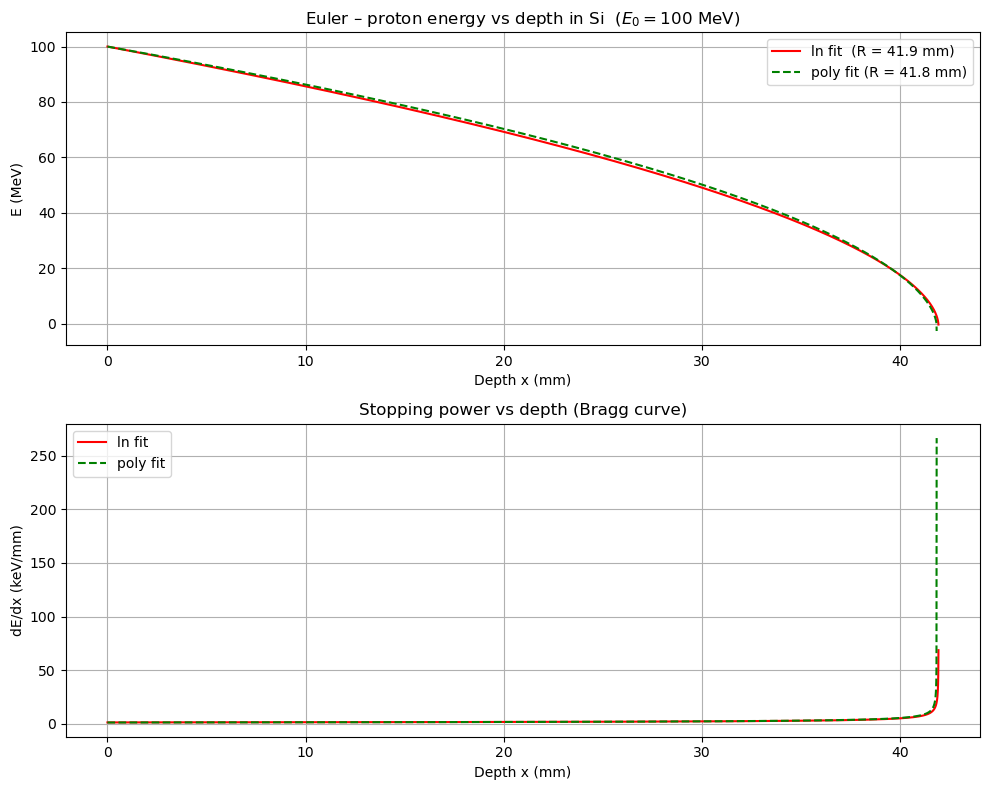

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

axs[0].plot(x_ln,   E_ln,   color='red',   label=f'ln fit  (R = {x_ln[-1]:.1f} mm)')
axs[0].plot(x_poly, E_poly, color='green', label=f'poly fit (R = {x_poly[-1]:.1f} mm)', linestyle='--')
axs[0].set_xlabel('Depth x (mm)')
axs[0].set_ylabel('E (MeV)')
axs[0].set_title(r'Euler – proton energy vs depth in Si  ($E_0 = 100$ MeV)')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(x_ln[:-1],   dEdx_ln,   color='red',   label='ln fit')
axs[1].plot(x_poly[:-1], dEdx_poly, color='green', label='poly fit', linestyle='--')
axs[1].set_xlabel('Depth x (mm)')
axs[1].set_ylabel('dE/dx (keV/mm)')
axs[1].set_title('Stopping power vs depth (Bragg curve)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# referencias

[1] J. B. Marion and F. C. Young, Nuclear Reaction Analysis: Graphs and Tables. North-Holland Publishing Company, 1968.